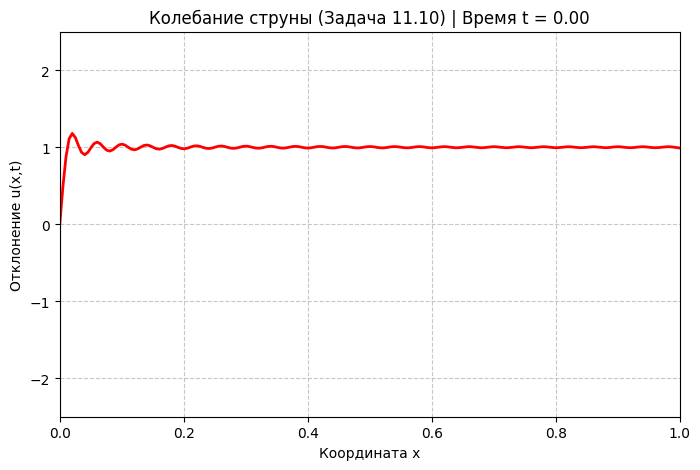

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import root_scalar

# --- Параметры задачи ---
L = 1.0      # Длина струны
h = 1.0      # Коэффициент упругого закрепления на правом конце
a = 4.0      # Параметр a (т.к. a^2 = 16)
N_terms = 50 # Количество членов ряда Фурье для аппроксимации

# --- 1. Нахождение корней трансцендентного уравнения ---
# Уравнение: tan(mu) = -mu / (h*L)
# Чтобы избежать проблем с асимптотами тангенса, решаем: sin(mu) + (mu/(h*L))*cos(mu) = 0
def equation(mu):
    return np.sin(mu) + (mu / (h * L)) * np.cos(mu)

mu_roots =[]
for n in range(1, N_terms + 1):
    # Корни лежат в интервалах (pi/2 + pi*(n-1), pi + pi*(n-1))
    left = np.pi/2 + np.pi*(n-1) + 1e-5
    right = np.pi + np.pi*(n-1)
    
    # Находим корень на заданном отрезке
    sol = root_scalar(equation, bracket=[left, right], method='brentq')
    mu_roots.append(sol.root)

mu = np.array(mu_roots)

# --- 2. Вычисление коэффициентов ряда ---
# Квадрат нормы
norm_sq = (L / 2) * (1 - np.sin(2 * mu) / (2 * mu))

# Коэффициенты An
A_n = (L * (1 - np.cos(mu))) / (mu * norm_sq)

# Коэффициенты Bn
B_n = (L**3 / (4 * mu**2 * norm_sq)) * (np.sin(mu) / mu - np.cos(mu))

# --- 3. Функция решения u(x, t) ---
def u(x, t):
    result = np.zeros_like(x)
    for i in range(N_terms):
        m = mu[i]
        # Временная часть T_n(t)
        T_n = A_n[i] * np.cos(4 * m * t / L) + B_n[i] * np.sin(4 * m * t / L)
        # Пространственная часть X_n(x)
        X_n = np.sin(m * x / L)
        
        result += T_n * X_n
    return result

# --- 4. Построение анимации ---
fig, ax = plt.subplots(figsize=(8, 5))
x_vals = np.linspace(0, L, 200)
line, = ax.plot(x_vals, u(x_vals, 0), color='red', lw=2)

ax.set_xlim(0, L)
ax.set_ylim(-2.5, 2.5) # Границы по оси Y (можно менять)
ax.set_title("Колебание струны (Задача 11.10)")
ax.set_xlabel("Координата x")
ax.set_ylabel("Отклонение u(x,t)")
ax.grid(True, linestyle='--', alpha=0.7)

# Функция для обновления кадров
def animate(frame):
    t = frame * 0.01 # Шаг по времени
    line.set_ydata(u(x_vals, t))
    ax.set_title(f"Колебание струны (Задача 11.10) | Время t = {t:.2f}")
    return line,

# Создаем анимацию (200 кадров, интервал 30 мс)
ani = animation.FuncAnimation(fig, animate, frames=200, interval=30, blit=True)

plt.show()